In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVR
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, RationalQuadratic

from scipy.interpolate import PchipInterpolator as Pchip
from scipy.interpolate import RBFInterpolator
from scipy.stats import pearsonr, spearmanr, skew, kurtosis

import matplotlib.pyplot as plt
#
from pathlib import Path

import json
import joblib
import hashlib
import sklearn
import skopt


# Import

In [2]:
cwd = Path.cwd()

version='v15'
sampling_data_path=Path(f'{cwd}/results_{version}/morris_samples_{version}.csv').resolve()
results_path=Path(f"{cwd}/results_{version}/results/raw_data").resolve()
field_data_path=Path(f"{cwd}/STIMTEC_example/BH10_20180718_40.6_SR_v2.csv")

raw_paths= list((results_path).glob("*.npy"))

file_paths= sorted(
    raw_paths,
    key= lambda p: int(p.stem.split("_")[2])
)

iter_list=[np.load(file,allow_pickle=True).item() for file in file_paths]
sampling_data=pd.read_csv(sampling_data_path,header=0)
field_data=pd.read_csv(field_data_path,header=0)



# Functions

In [21]:

def normalise_parity(original: pd.DataFrame | pd.Series | np.array,
                     predict: pd.DataFrame | pd.Series | np.array
                   ) -> None:
    
    normalise = (predict - np.min(original)) / (np.max(original) - np.min(original))
    return normalise

def y_fit_ln(grid_search, X_, y_log) -> None:
    """ Fit of GP regressor with best_estimator_ in ln"""

    best_pipeline = grid_search.best_estimator_

    y_predict = best_pipeline.predict(X_)

    mae = mean_absolute_error(y_log, y_predict)
    rmse = root_mean_squared_error(y_log, y_predict)
    y_nrmse = normalise_parity(y_log, y_predict)

    return mae, rmse, y_nrmse


def plot_fit_vs_obs( y_obs:np.array,  y_pred:np.array, grid_search, names: list[str] | str,target: str = 'NMRSE') -> plt.Figure:
    """ Plot crossvalidated vs Observed """
    """Normalise y_obs input internally """

    bundle_ = grid_search.cv_results_['params'][0]['gp__kernel']
    combo_key = names
    y_obs = normalise_parity(y_obs, y_obs)
    r2 = r2_score(y_obs, y_pred)


    fig, axs = plt.subplots(figsize=(7,6))
    axs.scatter(y_obs, y_pred, alpha= 0.7, edgecolors= "k", label = "Samples")

    min_val = min(y_obs.min(), y_pred.min())
    max_val = max(y_obs.max(), y_pred.max())
    axs.plot([min_val, max_val], [min_val, max_val], 'r--', label = '1:1 fit')

    axs.set_title(f"CV vs Observed {target}: {combo_key}\nKernel: {bundle_}")
    axs.set_xlabel(f'Observed {target}')
    axs.set_ylabel(f"Predicted {target}")

    text_str = f"R2 : {r2:.4f}"
    axs.text(0.05, 0.85, text_str, transform = axs.transAxes,
                   bbox=dict(boxstyle = 'round', facecolor= 'white', alpha = 0.7))

    axs.grid(True, ls= ':', alpha = 0.6)
    axs.legend(loc= 'lower right')
    plt.tight_layout()
    plt.show()

    return fig




def opt_skopt_gp( X, y, param_grid = None, n_splits: int = 5, random_state: int = 42 ):
    """
    Optimises GP for data 
    """

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('gp', GaussianProcessRegressor(
        n_restarts_optimizer= 5, 
        normalize_y= True,
        random_state= random_state
         ))
    ]) 

    if param_grid is None :
        # param_grid = {
        #     'gp__alpha'  : [1e-10, 1e-5, 1e-2, 1e-1],
        #     'gp__noise'  : ['gaussian', 1e-5, 1e-2,1e-1],
        #     'gp__kernel' : [
        #         C(1.0)*RBF(length_scale=1.0),
        #         C(1.0)*Matern(length_scale=1.0, nu=1.5),
        #         C(1.0)*Matern(length_scale=1.0, nu=2.5),
        #         C(1.0)*RationalQuadratic(length_scale=1.0, alpha=1.0),
        #     ]
        # }
        length_scales = np.logspace(-2,2, num= 5)
        rq_alphas = np.logspace(-2,2, num=5)

        param_grid = {
            'gp__alpha'  : np.logspace(-8,-2, num=7),
            'gp__kernel' : (
                [C(1.0)*RBF(length_scale=ls) for ls in length_scales] +
                [C(1.0)*Matern(length_scale=ls, nu=nu) for ls in length_scales for nu in [1.5, 2.5]] +
                [C(1.0)*RationalQuadratic(length_scale=ls, alpha=a) for ls in length_scales for a in rq_alphas]
            )
        }

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    scoring = {
        'MAE' : 'neg_mean_absolute_error',
        'R2'  : 'r2',
        'RMSE': 'neg_root_mean_squared_error'
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid= param_grid,
        cv=cv,
        scoring=scoring,
        refit= 'MAE', #reference fitting
        n_jobs= -1
    )

    grid_search.fit(X,y)

    cv_results = pd.DataFrame(grid_search.cv_results_)

    summary = pd.DataFrame ({
        'Params': cv_results['params'],
        'Mean MAE': -cv_results['mean_test_MAE'],
        'Std MAE': cv_results['std_test_MAE'],
        'Mean R2': cv_results['mean_test_R2'],
        'Mean RMSE': -cv_results['mean_test_RMSE']
    }).sort_values(by='Mean MAE', ascending= True).reset_index(drop= True)

    print('='*60)
    print('SKOPT GAUSSIAN PROCESS OPTIMISATION COMPLETE')
    print('='*60)
    print(f'Best Validation MAE: {-grid_search.best_score_:.6f}')
    print(f'Best Validation R2: {summary.loc[0, 'Mean R2']:.6f}')
    print(f'Best Validation RMSE: {summary.loc[0, 'Mean RMSE']:.6f}')
    print('='*60)
    print('Best Parameters:')
    for param, val in grid_search.best_params_.items():
        print(f' {param}: {val}')
    print('='*60)

    return grid_search, summary, cv

def tune_crossv_RBF(df_raw: pd.DataFrame, factor_cols: list[str], target_col = 'rmsle', n_splits:int=5 ) -> None:
    """ 
    Stack 3D factors, run KFold cv hyper grid search
    Generates out-of-fold CV prediction and oberserver
    Computes Cross correlation metrics (of subspaces)
    """
    combo_key = "_".join(factor_cols)

    y_ref = df_raw[target_col].values #log or normal y-target
    scaler_y = MinMaxScaler().fit(y_ref.reshape(-1,1))

    X_ref = df_raw[factor_cols].values
    scaler_X = MinMaxScaler().fit(X_ref)

    
    stacked_df = df_raw.groupby(factor_cols, as_index= False)[target_col].min().copy()

    y_raw = stacked_df[target_col].values
    X_raw = stacked_df[factor_cols].values

    y_norm= scaler_y.transform(y_raw.reshape(-1,1)).ravel()
    X_norm = scaler_X.transform(X_raw)

    param_grid = [
        # {'kernel' : 'thin_plate_spline', 'smoothing' : [0.0, 1e-4, 1e-2, 1e-1, 1.0]},
        # {'kernel' : 'cubic', 'smoothing' : [0.0, 1e-4, 1e-2, 1e-1,1.0]},
        # {'kernel' : 'gaussian', 'epsilon' : [0.0, 1e-4, 1e-2, 1e-1,1.0], 'smoothing': [0.0, 1e-4, 1e-2, 1e-1,1.0]},
        # {'kernel' : 'multiquadratic', 'epsilon' : [0.0, 1e-4, 1e-2, 1e-1,1.0], 'smoothing': [0.0, 1e-4, 1e-2, 1e-1,1.0]}

        {'kernel' : 'thin_plate_spline', 'smoothing' : np.logspace(-9,-2, num=8)},
        {'kernel' : 'cubic', 'smoothing' : np.logspace(-9,-2, num=8)},
        {'kernel' : 'gaussian', 'epsilon' : np.logspace(-2,2, num=9), 'smoothing': np.logspace(-9,-2, num=8)},
        {'kernel' : 'multiquadratic', 'epsilon' : np.logspace(-4,1, num=9), 'smoothing': np.logspace(-9,-2, num=8)}
    ]

    kf = KFold(n_splits= n_splits, shuffle= True, random_state=42)

    best_overall_score = float('inf')
    best_paras = {}
    best_oof_preds_norm = None

    for group in param_grid:
        kernel = group['kernel']
        epsilons = group.get('epsilon', [None])
        smoothings = group['smoothing']

        for eps in epsilons:
            for smooth in smoothings:
                oof_preds = np.zeros_like(y_norm)


                for train_idx, val_idx in kf.split(X_norm):
                    X_tr, X_val = X_norm[train_idx], X_norm[val_idx]
                    y_tr = y_norm[train_idx]


                    kwargs = {'kernel': kernel, 'smoothing': smooth}
                    if eps is not None:
                        kwargs['epsilon'] = eps

                    try: 
                        rbf = RBFInterpolator(X_tr, y_tr, **kwargs)
                        oof_preds[val_idx] = rbf(X_val)
                    except Exception:
                        oof_preds[val_idx] = np.nan

                 rmse = np.sqrt(np.mean((y_norm - oof_preds)**2))


                if rmse < best_overall_score:
                    best_overall_score = rmse
                    best_params = {'kernel': kernel, 'epsilon': eps, 'smoothing': smooth }
                    best_oof_preds_norm = oof_preds.copy()
        
        y_cv_pred = scaler_y.inverse_transform(best_oof_preds_norm.reshape(-1,1)).ravel()
              
        p_corr, _ = pearsonr(y_raw, y_cv_pred)
        s_corr, _ = spearmanr(y_raw, y_cv_pred)
        r2        = r2_score(y_raw, y_cv_pred)

        final_kwargs = {'kernel': best_params['kernel'], 'smoothing': best_params['smoothing']}
        if best_params['epsilon'] is not None:
            final_kwargs['epsilon'] = best_params ['epsilon']

        final_model = RBFInterpolator(X_norm, y_norm, **final_kwargs)

        #export saving machine ready archive
        bundle = {
            'factor_cols': factor_cols,
            'target_function': target_col,
            'combo_key' : combo_key,
            'model' : final_model,
            'scaler_X': scaler_X,
            'scaler_y' : scaler_y,
            'best_params': best_params,
            'evaluation_data': {
                'y_observed': y_raw,
                'y_cv_predicted': y_cv_pred,
                'pearson_corr': p_corr,
                'spearman_corr': s_corr,
                'r2_score': r2,
                'cv_nrmse_score': best_overall_score
            }
        }

        print(f"[{combo_key} Best kernel: {best_params['kernel']} | Pearson R: {p_corr:.4f} | R2: {r2:.4f}]")    
        return bundle
             


def objective_function(npyresult: dict,datafield: pd.DataFrame):

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    rmse=np.sqrt(np.mean((p_interp-p_field)**2))

    return rmse

def rmsle_ep(npyresult: dict,datafield: pd.DataFrame, epsilon: float = 100.0) -> np.array:
    "ln(y + epsilon ) transformation"

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    p_int_ln = np.log(p_interp + epsilon)
    p_field_ln = np.log(p_field + epsilon)

    rmsle=np.sqrt(np.mean((p_int_ln-p_field_ln)**2))

    return rmsle


def rmse_yeo(npyresult: dict,datafield: pd.DataFrame) -> np.array:
    "Yeo-Johnson transformation of p(r,t) and ppredict(r,t)"

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]).reshape(-1,1) #values, either pressure or other variable, i correct shape por method
    p_field=(datafield["Pint_downhole [MPa]_s"]*1e6).values.reshape(-1,1) #Pa values, to correct shape for method

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    pt = PowerTransformer(method= "yeo-johnson", standardize= False)

    p_field_yeo = pt.fit_transform(p_field)
    p_int_yeo = pt.transform(p_interp)

    rmse_yj = root_mean_squared_error(p_field_yeo, p_int_yeo)

    #print(pt.lambdas_[0])

    return rmse_yj

IndentationError: unindent does not match any outer indentation level (<string>, line 203)

# Input checkings

## Functions

In [4]:
def analysis_dist(series: pd.Series, name: str = None) -> dict:
    """ Histograms/KDE and distribution"""
    clean_series = series.dropna()
    col_name = name or series.name or "Variable"

    stats = {
        "Variable": col_name,
        "Min" : clean_series.min(),
        "Max" : clean_series.max(),
        "Mean" : clean_series.mean(),
        "Std" : clean_series.std(),
        "Skewness" : skew(clean_series),
        "Kurtosis" : kurtosis(clean_series)
    }

    print(f" - {col_name} - | Skew: {stats['Skewness']:.2f} | Kurtosis: {stats['Kurtosis']:.2f} |Range: [ {stats['Min']:.2e}, {stats['Max']:.2e}] ")

    plt.figure(figsize=(6,3))
    clean_series.plot(kind = "hist", bins = 20, density = True, alpha= 0.5, color = "Navy")
    clean_series.plot(kind = "kde", color = "red", lw = 2)
    plt.title(f"Distribution: {col_name} (Skew: {stats['Skewness']:.2f})")
    plt.xlabel(col_name)
    plt.grid(True, ls= "--", alpha= 0.5)
    plt.tight_layout()
    plt.show()

    return stats


## Processing

In [5]:
#prepare

# rmse=[objective_function(iter_,field_data) for iter_ in iter_list]
# rmse = np.array(rmse)
# sampling_data['rmse'] = rmse

rmsle=[rmsle_ep(iter_,field_data) for iter_ in iter_list]
rmsle = np.array(rmsle)
sampling_data['rmsle'] = rmsle

# rmse_yj=[rmse_yeo(iter_,field_data) for iter_ in iter_list]
# rmse_yj = np.array(rmse_yj)
# sampling_data['rmse_yj'] = rmse_yj


 - Pre-stack_sf0 - | Skew: 0.02 | Kurtosis: -1.45 |Range: [ 2.09e-10, 8.50e-04] 


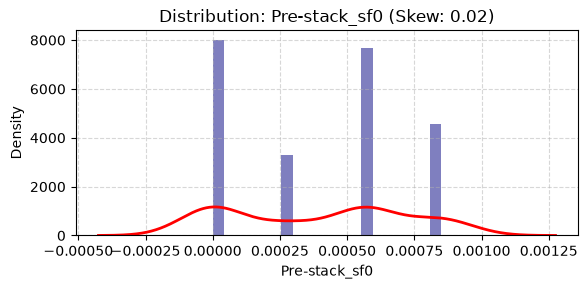

 - Pre-stack_pjack - | Skew: 0.10 | Kurtosis: -1.22 |Range: [ 3.10e+06, 3.60e+06] 


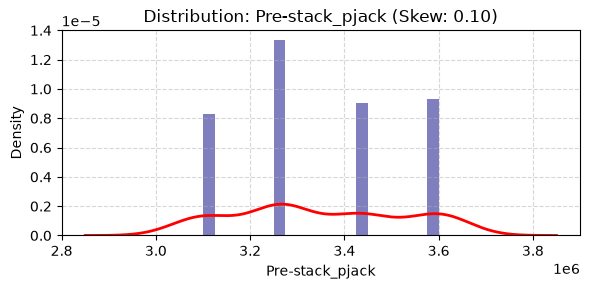

 - Pre-stack_wr - | Skew: -0.13 | Kurtosis: -1.46 |Range: [ 2.00e+05, 5.00e+05] 


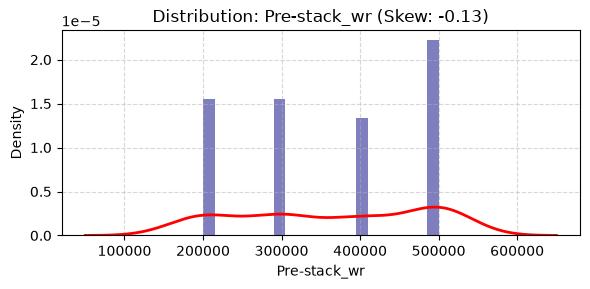

 - Pre-stack_L - | Skew: 0.05 | Kurtosis: -1.35 |Range: [ 5.00e-01, 2.00e+01] 


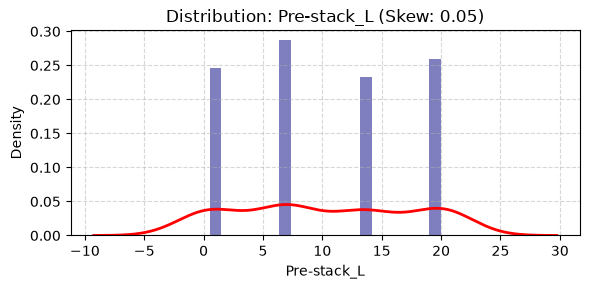

 - Pre-stack_rmsle - | Skew: 2.30 | Kurtosis: 4.70 |Range: [ 2.35e-01, 1.37e+00] 


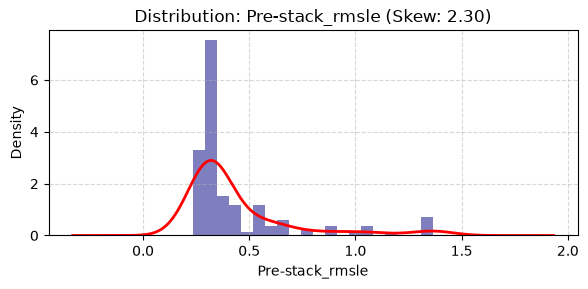

In [6]:
#pre-stack checking

cols_check = sampling_data.columns.tolist()
pre_stats = {}
for col in cols_check:
    pre_stats[col] = analysis_dist(sampling_data[col],name= f"Pre-stack_{col}")

In [7]:
#stacked checking
def df_stacking(df_raw: pd.DataFrame,factor_cols:list[str], target_col:str = 'rmse'):

    stacked_df = df_raw.groupby(factor_cols, as_index= False)[target_col].min()
    return stacked_df

combos = {'combo_1':['pjack','wr','L'],
          'combo_2': ['pjack','wr','sf0']
}

stacked_df= {}
for key_, value in combos.items():
    stacked_df[key_] = df_stacking(sampling_data, value, 'rmsle') # adjus rmse or rmsle or rmse_yj



 - Post-stack_pjack - | Skew: -0.03 | Kurtosis: -1.30 |Range: [ 3.10e+06, 3.60e+06] 


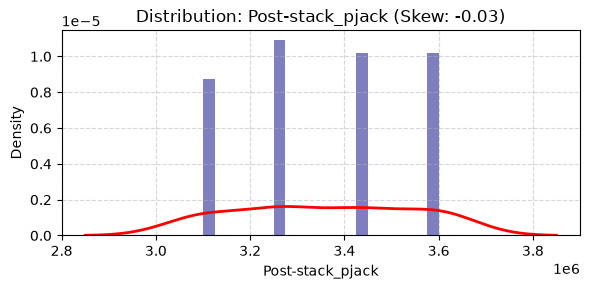

 - Post-stack_wr - | Skew: -0.02 | Kurtosis: -1.45 |Range: [ 2.00e+05, 5.00e+05] 


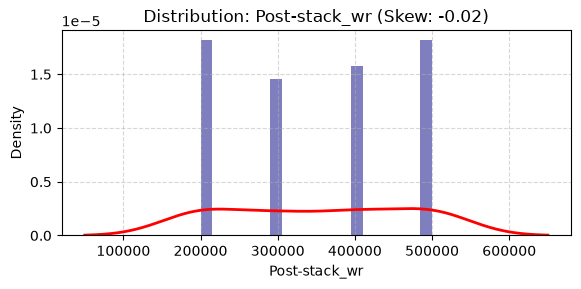

 - Post-stack_L - | Skew: -0.03 | Kurtosis: -1.26 |Range: [ 5.00e-01, 2.00e+01] 


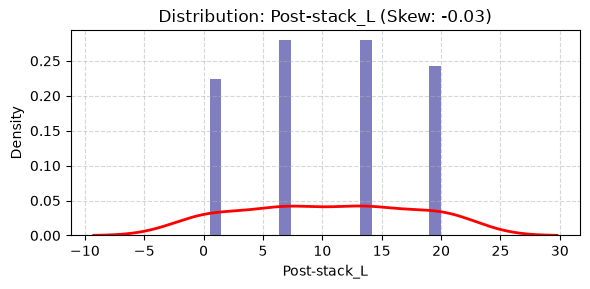

 - Post-stack_rmsle - | Skew: 3.52 | Kurtosis: 15.39 |Range: [ 2.35e-01, 6.77e-01] 


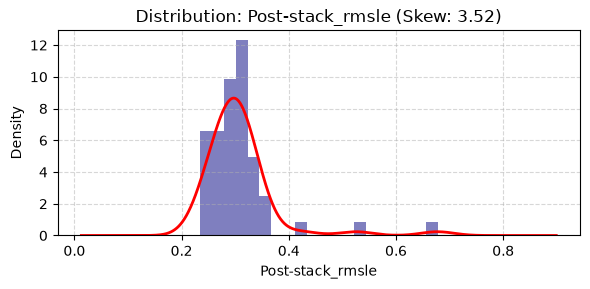

In [8]:
post_stats = {}
combo_check = 'combo_1'
for name, slice in stacked_df[combo_check].items():
   post_stats[name] = analysis_dist(slice, name= f"Post-stack_{name}")


## Transforming factors/variables with high skew-range

The transformation is given in new variables with log10

In [6]:
sampling_data['log_sf0'] = np.log(sampling_data['sf0'])


# Gaussian Process Regressor Hyper-p tunning

In [7]:
#slice-preparing
names = ['pjack','wr','log_sf0','L']
target_t = ['rmsle']
names_t = names + target_t

sampling_data_ready= sampling_data[names_t].copy()

In [8]:
grid_search, summary, cv = opt_skopt_gp(sampling_data_ready[names],sampling_data_ready[target_t])

SKOPT GAUSSIAN PROCESS OPTIMISATION COMPLETE
Best Validation MAE: 0.011796
Best Validation R2: 0.990326
Best Validation RMSE: 0.022244
Best Parameters:
 gp__alpha: 0.0001
 gp__kernel: 1**2 * Matern(length_scale=10, nu=2.5)


In [9]:


_, _, y_nrmse = y_fit_ln(grid_search, sampling_data_ready[names],sampling_data_ready[target_t])


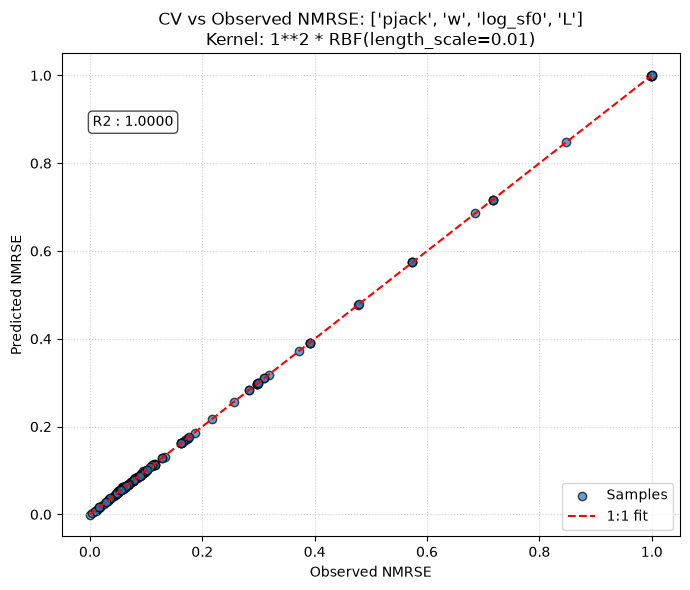

In [ ]:
names_title = ['pjack','w','log_sf0','L']
fig0 = plot_fit_vs_obs( sampling_data_ready[target_t].values, y_nrmse, grid_search,names_title, 'NMRSE')

# fig0.savefig(fname=cwd/f'Morris_opt_BH10_40_6_GP_{version}.pdf',  #save to potential untracked folder
#             format="pdf",
#             bbox_inches='tight',
#             pad_inches=0.05
#             ) 

## Save metadata GP

In [12]:
def export_tunning_results(grid_search, X_df, feature_names, export_prefix='gp_tunning'):
    best_pipeline = grid_search.best_estimator_
    best_gp = best_pipeline.named_steps['gp']
    scaler = best_pipeline.named_steps['scaler']

    hyperparams_log = {
        "metadata" : {
            "n_samples": X_df.shape[0],
            "n_features" : X_df.shape[1],
            "feature_names" : feature_names,
            "data_hash" : hashlib.md5(X_df.values.tobytes()).hexdigest(),
            "environment": {
                "sklearn_version" : sklearn.__version__,
                "skopt_version" : skopt.__version__
            }
        },
        "performance_metrics": {
            "best_cv_mae": float(-grid_search.best_score_),
            "mean_test_r2": float(grid_search.cv_results_['mean_test_R2'][grid_search.best_index_]),
            "mean_test_rmse": float(-grid_search.cv_results_['mean_test_RMSE'][grid_search.best_index_])
        },
        "scaling_paramters" : {
            "alpha": str(best_gp.kernel_),
            "kernel_str": str(best_gp.kernel_),
            "normalise_y": best_gp.normalize_y,
            "n_restarts_optimizer": best_gp.n_restarts_optimizer
        }
    }

    json_filename = f"{export_prefix}_config.json"
    with open(json_filename, "w") as f:
        json.dump(hyperparams_log, f, indent=4)

    pipeline_filename = f"{export_prefix}_pipeline.pkl"
    joblib.dump(best_pipeline, pipeline_filename)

    print(f"Traceability metadata exported succesfully:")
    print(f" JSON Report: {json_filename}")
    print(f" Pipeline PKL : {pipeline_filename}")


In [ ]:
#export_tunning_results(grid_search, sampling_data,list(sampling_data.keys()),f"gp_tunning_{version}")

Traceability metadata exported succesfully:
 JSON Report: gp_tunning_v15_config.json
 Pipeline PKL : gp_tunning_v15_pipeline.pkl


# RBF Interpolator

In [22]:
columns = ['pjack','wr','L']
target_t = ['rmsle']
columns_t = columns + target_t

sampling_data_ready= sampling_data[columns_t].copy()

In [23]:
bundle = tune_crossv_RBF(sampling_data_ready, columns)

[pjack_wr_L Best kernel: thin_plate_spline | Pearson R: -0.1478 | R2: -0.7507]


In [24]:

def plot_cv_vs_obs(bundle_, base_norm, combo_name: list[str] = None):
    """ Plot crossvalidated NRMSE vs Observed NRMSE"""
    if isinstance(bundle_, str):
        bundle_= joblib.load(bundle_)
    else:
        bundle_= bundle_

    eval_data = bundle_['evaluation_data']
    if combo_name is None:
        combo_key = bundle_['combo_key']
    else:
        combo_key = combo_name

    y_obs = eval_data['y_observed']
    y_pred = eval_data['y_cv_predicted']

    y_obs = normalise_parity(base_norm, y_obs )
    y_pred = normalise_parity(base_norm, y_pred )

    p_corr = eval_data ['pearson_corr']
    s_corr = eval_data ['spearman_corr']
    r2 = eval_data ['r2_score']

    fig, axs= plt. subplots(figsize=(7,6))
    plt.scatter(y_obs, y_pred, alpha= 0.7, edgecolors= "k", label = "Min-stacked samples")

    # min_val = min(y_obs.min(), y_pred.min())
    # max_val = max(y_obs.max(), y_pred.max())
    # axs.plot([min_val,max_val], [min_val,max_val], 'r--', label = '1:1 fit')
    axs.plot([0,1], [0,1], 'r--', label = '1:1 fit')

    axs.set_title(f"CV vs Observed NRMSE: {combo_key}\nKernel: {bundle_['best_params']['kernel']}")
    axs.set_xlabel('Observed NRMSE')
    axs.set_ylabel("Cross-Validated (K-Fold) predicted NRMSE")

    text_str = f"Pearson R: {p_corr:.4f}\nSpearman R: {s_corr:.4f}\nR2 : {r2:.4f}"
    axs.text(0.05, 0.85, text_str, transform = axs.transAxes,
                   bbox=dict(boxstyle = 'round', facecolor= 'white', alpha = 0.7))

    axs.grid(True, ls= ':', alpha = 0.6)
    axs.legend(loc= 'lower right')
    plt.tight_layout()
 
    return fig

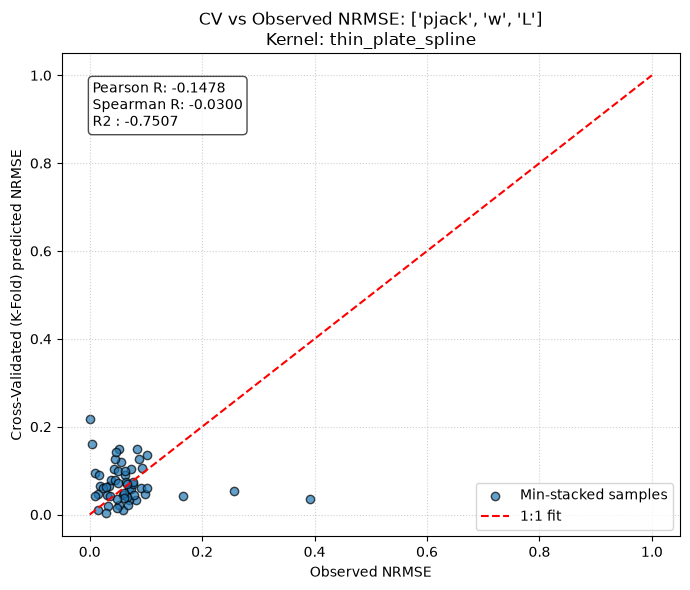

In [ ]:
combo_name = ['pjack','w','L']#optional,and must be the same as columns evaluated
fig1 = plot_cv_vs_obs(bundle,sampling_data_ready[target_t],combo_name)

# fig1.savefig(fname=cwd/f'interpolator_fitt
# ing_BH10_40_6_opt5_{version}.pdf',  #save fixing name
#             format="pdf",
#             bbox_inches='tight',
#             pad_inches=0.05
#             ) 

## Save metadata RBF

In [ ]:
# export_prefix = 'rbf_3d'
# opt_name =  "opt5"
# export_filename = f"{export_prefix}_{opt_name}_{version}.joblib"
# joblib.dump(bundle,export_filename)

['rbf_3d_opt5_v15.joblib']